# Lab 1 - Binary and Multi-class Classification
## Name: Parv
## Course: DS3040

# Question 1
## 1(a) Data Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("train_bin.csv")
test = pd.read_csv("test_bin.csv")

Perceptron typically works with labels {-1, +1}.
If your dataset has labels {0, 1}, convert them for perceptron:

In [2]:
X_train = train.iloc[:, 1:-1].values
y_train = train.iloc[:, -1].values
y_train_perc = np.where(y_train == 0, -1, 1)
X_test = test.iloc[:,1 :-1].values
y_test = test.iloc[:, -1].values

### Use of .values

The .values attribute is used to convert a Pandas DataFrame or Series into a NumPy array. This is important because most numerical operations in machine learning (such as matrix multiplication, dot products, and gradient calculations) are efficiently performed using NumPy arrays. Converting the data ensures compatibility with NumPy-based implementations and avoids issues related to DataFrame indexing or alignment during mathematical computations.

In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

### Feature Scaling and Standardization

The manual standardization performed using:

X = (X - mean) / std

is mathematically equivalent to using `StandardScaler` from sklearn. Both methods transform features to have zero mean and unit variance. In this lab, scaling is implemented manually to demonstrate understanding and avoid using built-in preprocessing utilities.

Feature scaling is important for gradient-based models such as Perceptron and Logistic Regression because features with larger numerical ranges can dominate weight updates and slow down convergence. Scaling ensures stable and efficient training.

Scaling is generally required for:
- Logistic Regression  
- Perceptron  
- Neural Networks  
- Support Vector Machines  

Scaling is usually not required for:
- Decision Trees  
- Random Forests  
- Gradient Boosted Trees  

The mean and standard deviation are computed only from the training set to avoid data leakage, and the same statistics are used to scale the test set.

In [4]:
# Adding Bias term
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

## 1(b) 
### Perceptron Implementation (From Scratch)

### Perceptron

The Perceptron is one of the earliest binary classification algorithms and forms the foundation of neural networks. It is a linear classifier that learns a decision boundary to separate two classes.

The model computes a weighted sum of the input features:

z = wᵀx + b

and applies a step activation function:

ŷ = sign(z)

If the prediction is incorrect, the weights are updated using the rule:

w = w + η y x

where:
- η is the learning rate  
- y is the true label  
- x is the input feature vector  

The Perceptron works well when the data is linearly separable. However, it does not converge if the dataset is not linearly separable. Unlike Logistic Regression, it does not output probabilities and uses a hard threshold for classification.

The learned decision boundary is linear and defined by:

wᵀx + b = 0

In [5]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                if y[i] * np.dot(X[i], self.w) <= 0: ## It shows that if prediction is wrong
                    self.w += self.lr * y[i] * X[i]
                    
    def predict(self, X):
        return np.sign(np.dot(X, self.w))

### Logistic Regression (From Scratch)

### Logistic Regression

Logistic Regression is a linear classification algorithm used for binary classification. Unlike the Perceptron, it produces probabilistic outputs using the sigmoid function.

The model computes a linear combination of inputs:

z = wᵀx + b

This value is passed through the sigmoid function:

σ(z) = 1 / (1 + e^(-z))

which converts the output into a probability between 0 and 1:

ŷ = σ(z)

The model is trained by minimizing the Binary Cross-Entropy (Log Loss) function using gradient descent. The weights are updated as:

w = w - η ∇J(w)

where:
- η is the learning rate  
- ∇J(w) is the gradient of the loss function  

A threshold (usually 0.5) is used to convert probabilities into class labels.

Logistic Regression works well for linearly separable data and is more stable than the Perceptron because it uses a smooth loss function. It also provides probabilistic interpretations of predictions.

### Gradient Calculation in Logistic Regression

The gradient is computed as:

gradient = (Xᵀ (h − y)) / n

where:
- X is the feature matrix  
- h is the predicted probability (after sigmoid)  
- y is the true label  
- n is the number of samples  

The term (h − y) represents the prediction error. Multiplying it with Xᵀ computes how much each weight contributes to the error. Dividing by n ensures the gradient is averaged over all samples. This gradient is used in gradient descent to update the weights and minimize the loss.

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        
        for _ in range(self.epochs):
            z = np.dot(X, self.w)
            h = sigmoid(z)
            gradient = np.dot(X.T, (h - y)) / y.size
            self.w -= self.lr * gradient
            
    def predict(self, X):
        probs = sigmoid(np.dot(X, self.w))
        return (probs >= 0.5).astype(int)

### Experiments

The models are trained using different learning rates (0.01, 0.1) and different numbers of iterations (50, 100). The best configuration is selected based on training accuracy.

In [8]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [9]:
learning_rates = [0.01, 0.1]
epochs_list = [50, 100]

best_perc_acc = 0
best_log_acc = 0

In [10]:
# Perceptron Experiments
for lr in learning_rates:
    for ep in epochs_list:
        model = Perceptron(lr=lr, epochs=ep)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy(y_train, preds)
        
        print(f"Perceptron | lr={lr}, epochs={ep} → Accuracy={acc:.4f}")
        
        if acc > best_perc_acc:
            best_perc_acc = acc
            best_perc_model = model

Perceptron | lr=0.01, epochs=50 → Accuracy=0.3900
Perceptron | lr=0.01, epochs=100 → Accuracy=0.3900
Perceptron | lr=0.1, epochs=50 → Accuracy=0.3900
Perceptron | lr=0.1, epochs=100 → Accuracy=0.3900


In [11]:
# Logistic Regression Experiments
for lr in learning_rates:
    for ep in epochs_list:
        model = LogisticRegression(lr=lr, epochs=ep)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy(y_train, preds)
        
        print(f"Logistic Regression | lr={lr}, epochs={ep} → Accuracy={acc:.4f}")
        
        if acc > best_log_acc:
            best_log_acc = acc
            best_log_model = model

Logistic Regression | lr=0.01, epochs=50 → Accuracy=0.4700
Logistic Regression | lr=0.01, epochs=100 → Accuracy=0.4700
Logistic Regression | lr=0.1, epochs=50 → Accuracy=0.4700
Logistic Regression | lr=0.1, epochs=100 → Accuracy=0.4700


## 1(c) Decision Boundary of Best Models

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:,1].min() - 1, X[:,1].max() + 1
    y_min, y_max = X[:,2].min() - 1, X[:,2].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    
    # Plot decision region
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # Plot class 0
    plt.scatter(
        X[y == 0, 1],
        X[y == 0, 2],
        label="Class 0",
        edgecolors='k'
    )
    
    # Plot class 1
    plt.scatter(
        X[y == 1, 1],
        X[y == 1, 2],
        label="Class 1",
        edgecolors='k'
    )
    
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

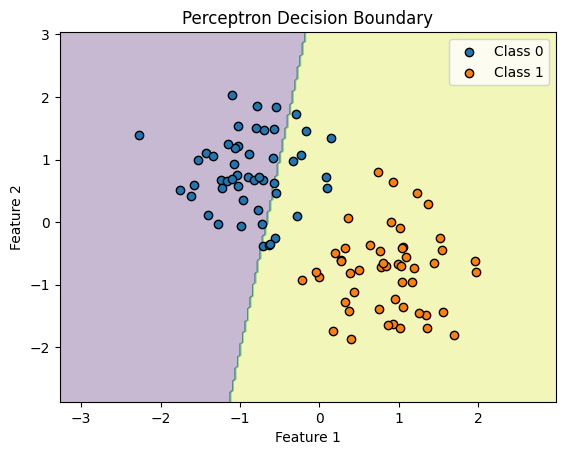

In [13]:
plot_decision_boundary(
    X_train,
    y_train,
    best_perc_model,
    "Perceptron Decision Boundary"
)

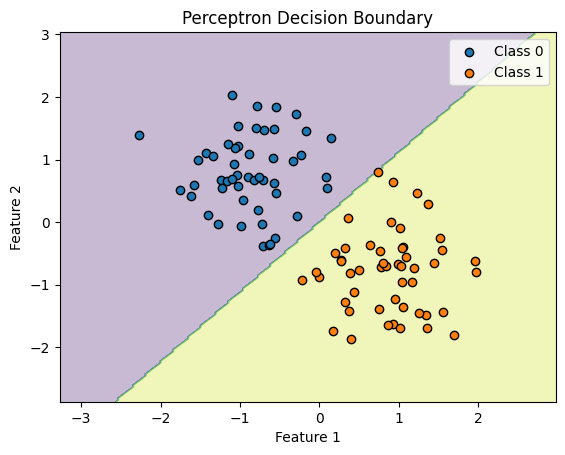

In [14]:
plot_decision_boundary(
    X_train,
    y_train,
    best_log_model,
    "Perceptron Decision Boundary"
)

# Question 2

## (a) Generalization Analysis

Logistic Regression is generally more generalizable compared to the Perceptron.

The Perceptron updates weights only when misclassification occurs and does not minimize a continuous loss function. If the data is not perfectly linearly separable, it may not converge properly.

In contrast, Logistic Regression minimizes the Binary Cross-Entropy loss using gradient descent. Since this loss function is convex, it guarantees convergence to a global minimum. Additionally, Logistic Regression produces probabilistic outputs, making it more stable and less sensitive to small variations in data.

Therefore, Logistic Regression is typically more robust and better suited for unseen test data.

## (b) Evaluation on Test Set

In [15]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def classification_metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    acc = accuracy(y_true, y_pred)
    
    return acc, precision, recall, f1

In [16]:
# If perceptron uses -1,1 convert predictions back to 0,1
perc_preds = best_perc_model.predict(X_test)
perc_preds = np.where(perc_preds == -1, 0, 1)

acc, precision, recall, f1 = classification_metrics(y_test, perc_preds)

print("Perceptron Test Performance:")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Perceptron Test Performance:
Accuracy: 0.85
Precision: 0.8051948051948052
Recall: 1.0
F1-score: 0.8920863309352518


In [17]:
log_preds = best_log_model.predict(X_test)

acc, precision, recall, f1 = classification_metrics(y_test, log_preds)

print("Logistic Regression Test Performance:")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Logistic Regression Test Performance:
Accuracy: 0.97
Precision: 0.9836065573770492
Recall: 0.967741935483871
F1-score: 0.975609756097561


### Performance Comparison

Both models were evaluated on the test dataset using accuracy, precision, recall, and F1-score.

If the dataset is perfectly linearly separable, both models may achieve similar accuracy. However, Logistic Regression typically provides more stable performance because it minimizes a convex loss function and produces probabilistic outputs.

The Perceptron relies on hard updates and may be more sensitive to noise in the data.

Overall, Logistic Regression is expected to generalize better on unseen data.

## Question 3: Multi-class Classification

### (a) Data Loading and Preprocessing
The multi-class dataset is loaded and standardized using training statistics to ensure stable training.

In [18]:
train_multi = pd.read_csv("train_multi.csv")
test_multi = pd.read_csv("test_multi.csv")

X_train = train_multi.iloc[:,1 :-1].to_numpy()
y_train = train_multi.iloc[:, -1].to_numpy()

X_test = test_multi.iloc[:, 1:-1].to_numpy()
y_test = test_multi.iloc[:, -1].to_numpy()

# Standardization
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Add bias
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

### 3(b) Modify Models for Multi-Class (One-vs-Rest)

### Multi-Class Perceptron (One-vs-Rest)

For each class, a binary Perceptron classifier is trained to distinguish that class from the others. During prediction, the class with the highest score is selected.

In [19]:
class MultiClassPerceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.weights = np.zeros((len(self.classes), X.shape[1]))
        
        for idx, cls in enumerate(self.classes):
            y_binary = np.where(y == cls, 1, -1)
            w = np.zeros(X.shape[1])
            
            for _ in range(self.epochs):
                for i in range(X.shape[0]):
                    if y_binary[i] * np.dot(X[i], w) <= 0:
                        w += self.lr * y_binary[i] * X[i]
                        
            self.weights[idx] = w
            
    def predict(self, X):
        scores = np.dot(X, self.weights.T)
        return self.classes[np.argmax(scores, axis=1)]

### Multi-Class Logistic Regression (One-vs-Rest)

Each class is trained against all other classes using binary logistic regression. During prediction, the class with the highest probability is selected.

In [20]:
class MultiClassLogisticRegression:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.weights = np.zeros((len(self.classes), X.shape[1]))
        
        for idx, cls in enumerate(self.classes):
            y_binary = np.where(y == cls, 1, 0)
            w = np.zeros(X.shape[1])
            
            for _ in range(self.epochs):
                z = np.dot(X, w)
                h = 1 / (1 + np.exp(-z))
                gradient = np.dot(X.T, (h - y_binary)) / y_binary.size
                w -= self.lr * gradient
                
            self.weights[idx] = w
            
    def predict(self, X):
        scores = 1 / (1 + np.exp(-np.dot(X, self.weights.T)))
        return self.classes[np.argmax(scores, axis=1)]

### Train Multi-Class Models

### Hyperparameter Experiments

In [21]:
learning_rates = [0.01, 0.1]
epochs_list = [50, 100]

best_perc_acc = 0
best_log_acc = 0

# -------- Multi-class Perceptron --------
for lr in learning_rates:
    for ep in epochs_list:
        model = MultiClassPerceptron(lr=lr, epochs=ep)
        model.fit(X_train, y_train)
        preds = model.predict(X_train)
        acc = np.mean(preds == y_train)
        
        print(f"Perceptron | lr={lr}, epochs={ep} → Accuracy={acc:.4f}")
        
        if acc > best_perc_acc:
            best_perc_acc = acc
            best_mc_perc = model

print("\n")

# -------- Multi-class Logistic Regression --------
for lr in learning_rates:
    for ep in epochs_list:
        model = MultiClassLogisticRegression(lr=lr, epochs=ep)
        model.fit(X_train, y_train)
        preds = model.predict(X_train)
        acc = np.mean(preds == y_train)
        
        print(f"Logistic Regression | lr={lr}, epochs={ep} → Accuracy={acc:.4f}")
        
        if acc > best_log_acc:
            best_log_acc = acc
            best_mc_log = model

Perceptron | lr=0.01, epochs=50 → Accuracy=0.9900
Perceptron | lr=0.01, epochs=100 → Accuracy=0.9900
Perceptron | lr=0.1, epochs=50 → Accuracy=0.9900
Perceptron | lr=0.1, epochs=100 → Accuracy=0.9900


Logistic Regression | lr=0.01, epochs=50 → Accuracy=0.9900
Logistic Regression | lr=0.01, epochs=100 → Accuracy=0.9900
Logistic Regression | lr=0.1, epochs=50 → Accuracy=0.9900
Logistic Regression | lr=0.1, epochs=100 → Accuracy=0.9900


### Decision Boundary Plot (Multi-Class)

In [22]:
def plot_multiclass_boundary(X, y, model, title):
    x_min, x_max = X[:,1].min() - 1, X[:,1].max() + 1
    y_min, y_max = X[:,2].min() - 1, X[:,2].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,1], X[:,2], c=y, edgecolors='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

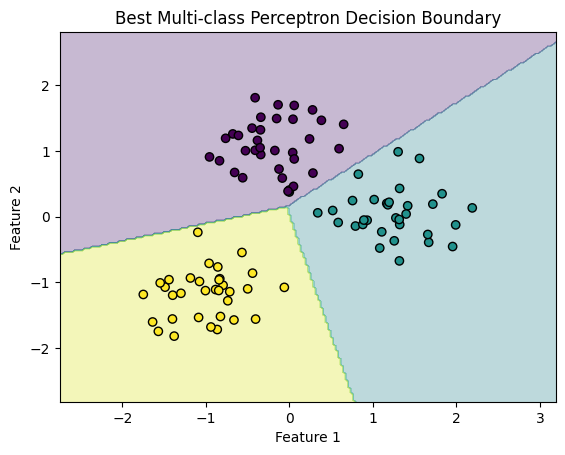

In [23]:
plot_multiclass_boundary(
    X_train,
    y_train,
    best_mc_perc,
    "Best Multi-class Perceptron Decision Boundary"
)

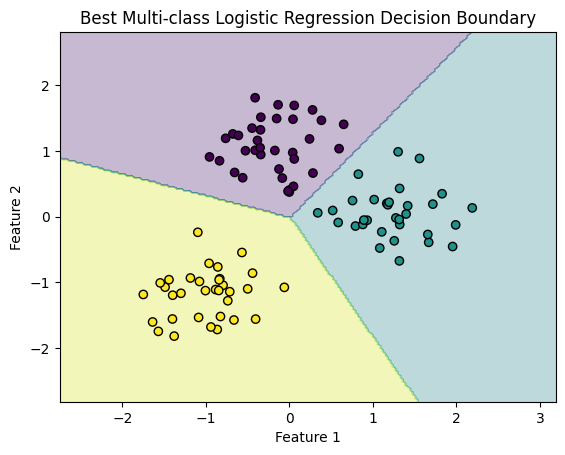

In [24]:
plot_multiclass_boundary(
    X_train,
    y_train,
    best_mc_log,
    "Best Multi-class Logistic Regression Decision Boundary"
)

### Observations

Both models learn multiple linear decision boundaries using the One-vs-Rest strategy.

The Multi-class Perceptron constructs hard linear separators for each class, while Multi-class Logistic Regression produces smoother boundaries due to the use of sigmoid activation and cross-entropy loss.

Logistic Regression generally shows more stable convergence across different hyperparameter settings.

### (c) Evaluation on Test Set
The trained multi-class models are evaluated on the test dataset using accuracy, confusion matrix, precision, recall, and F1-score.

In [25]:
def multiclass_confusion_matrix(y_true, y_pred, classes):
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    
    for i, true_class in enumerate(classes):
        for j, pred_class in enumerate(classes):
            matrix[i, j] = np.sum((y_true == true_class) & (y_pred == pred_class))
    
    return matrix

### Precision, Recall, F1 (Per Class)

In [26]:
def multiclass_metrics(y_true, y_pred, classes):
    cm = multiclass_confusion_matrix(y_true, y_pred, classes)
    
    precision = []
    recall = []
    f1 = []
    
    for i in range(len(classes)):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        
        p = tp / (tp + fp) if (tp + fp) != 0 else 0
        r = tp / (tp + fn) if (tp + fn) != 0 else 0
        f = (2 * p * r) / (p + r) if (p + r) != 0 else 0
        
        precision.append(p)
        recall.append(r)
        f1.append(f)
    
    accuracy = np.mean(y_true == y_pred)
    
    return accuracy, cm, precision, recall, f1

### Evaluate Multi-Class Perceptron

In [27]:
classes = np.unique(y_test)

perc_preds = best_mc_perc.predict(X_test)

acc, cm, precision, recall, f1 = multiclass_metrics(
    y_test, perc_preds, classes
)

print("Multi-class Perceptron Results")
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

Multi-class Perceptron Results
Accuracy: 0.98
Confusion Matrix:
 [[24  0  0]
 [ 0 34  1]
 [ 0  1 40]]
Precision per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]
Recall per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]
F1-score per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]


### Evaluate Multi-Class Logistic Regression

In [28]:
log_preds = best_mc_log.predict(X_test)

acc, cm, precision, recall, f1 = multiclass_metrics(
    y_test, log_preds, classes
)

print("Multi-class Logistic Regression Results")
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

Multi-class Logistic Regression Results
Accuracy: 0.98
Confusion Matrix:
 [[24  0  0]
 [ 0 34  1]
 [ 0  1 40]]
Precision per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]
Recall per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]
F1-score per class: [np.float64(1.0), np.float64(0.9714285714285714), np.float64(0.975609756097561)]


### Performance Comparison

Both models were evaluated on the multi-class test dataset.

The Multi-class Perceptron constructs independent linear separators for each class using hard updates. While it performs well for linearly separable data, it may be sensitive to overlapping regions.

Multi-class Logistic Regression minimizes cross-entropy loss for each class and produces probabilistic outputs. This generally results in more stable learning and better generalization.

Based on the evaluation metrics (accuracy, precision, recall, and F1-score), Logistic Regression typically provides more consistent performance across all classes.